# Data Analytics - Summative Assessment One

## Business Case
As a part of a software development team for Censored, I have been asked to conduct data-driven analysis of games on the online gaming marketplace Steam.  The purpose of this analysis is to make informed data-driven decisions on what type of game the organisation should produce in order to maximise audience reach, engagement, and cost-effectiveness.  

By examining existing games on Steam, this project aims to identify patterns in the games' popularity, reception, player engagement, tags, genres, or combinations of genres.  The aim of these insights is to create a game with the maximum reach possible to provide the greatest return on investment.  


## Data acquisition 





### Import Python Modules 🐍

In [60]:
import pandas as pd # Pandas is a module for data manipulation, it makes use of dataframe objects to store and manipulate data.
import numpy as np # Numpy is a module for numerical computing, it provides support for arrays and matrices and mathematical functions.
import matplotlib.pyplot as plt # Matplotlib is a module for data visualization.
import seaborn as sns # Seaborn is a module for statistical data visualization, built on top of Matplotlib.
import plotly.express as px # Plotly Express is a module for making interactive visualisations.

### Loading dataset 📥

In [61]:
steam_games_df = pd.read_csv("steam_games.csv")

This creates a pandas dataframe object from the origional csv file.  The reason the dataframe object are so effective for data analysis is that they have built in methods and functions which enable the user to quickly and easily inspect and transform the data.

### Dataset source and description
This analysis uses the [Steam Games Dataset](https://www.kaggle.com/datasets/fronkongames/steam-games-dataset), a public open dataset from Kaggle.  The dataset provides comprehensive information on the games sold on Steam, including commercial, technical and user engagement data.

## Initial data inspection 🧭

### Preview the data

In [62]:
steam_games_df.head(2)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN


On initially looking at the dataframes head it apears that there is a missing column name.  Due to 'supported languages' being languages, 'about the game' being text and price being in the format x.xx it makes sense that the 'DiscountDLC Count' should be two columns.  This is a mistake present in the kaggle dataset.  To fix 'DiscountDLC Count' was split into 'Discount' and 'DLC Count' by a comma.  
  
Overall this isn't very usful as it only shows a few columns potentially hiding errors.

In [63]:
steam_games_df.shape

(122611, 40)

The shape of the dataframe is 40 columns and 122611 rows.  This means that there are 40 columns and 122611 rows.  40 columns are too many for this investigation, any extra colums will just confuse.  Furthermore there are way to many rows for the data to ever be manually checked by a human. 

### Check columns

In [64]:
steam_games_df.columns

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='str')

Column names are mostly self explanatory with the exeption of a few such as 'Posative' and 'Negative' which need aditional context to make sense.

### Check datatypes

In [65]:
steam_games_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122611 non-null  int64  
 1   Name                        122610 non-null  str    
 2   Release date                122611 non-null  str    
 3   Estimated owners            122611 non-null  str    
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  int64  
 6   Price                       122611 non-null  float64
 7   Discount                    122611 non-null  int64  
 8   DLC count                   122611 non-null  int64  
 9   About the game              114162 non-null  str    
 10  Supported languages         122611 non-null  str    
 11  Full audio languages        122611 non-null  str    
 12  Reviews                     12070 non-null   str    
 13  Header image             

Overall the dataframe has a mix of quantitative and qualitative data.  Data type is mostly correct except columns like 'release date' which should be a date and 'Estimated Owners' should be an integer.  There are also a few unusable columns due to lack of data such as 'Movies', 'Notes' or 'Score Rank'.

In [66]:
steam_games_df.describe()

,AppID,Peak CCU,Required age,Price,Discount,DLC count,Metacritic score,User score,Positive,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Movies
count,1.226110e+05,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,40.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,122611.000000,0.0
mean,1.985386e+06,5.459332e+01,0.167611,4.765091,18.353663,0.545856,2.564941,0.024549,1.044986e+03,1.691974e+02,99.175000,18.087015,9.618250e+02,2.080232e+02,13.789268,1.735705e+02,14.722170,NaN
std,1.087595e+06,3.729452e+03,1.653591,12.531030,28.858970,14.516026,13.660559,1.394901,2.809173e+04,5.374645e+03,0.675107,141.493879,2.187880e+04,1.121768e+04,270.378053,1.120254e+04,294.509615,NaN
min,1.000000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
25%,1.063175e+06,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,99.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
50%,1.907380e+06,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,99.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
75%,2.869560e+06,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,100.000000,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
max,4.264350e+06,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,100.000000,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,NaN


.describe() shows sumary statistics for numerical colums.  
Quite a few of the third quartile are 0, this is due to a large number of 0 results biasing the data some such as 'DLC Count' are probuably legitimate however for 'User score' and 'Metacritic score' no score is probuably recorded as 0.  
Columns like 'Positive', 'Negative' and 'Recomondation' columns have a median of 5, 1 and 0 respectivly but means of 1 x 10E3, 2 x 10E2 and 2 x 10E2, this large difference between the median and mean sugests a few extremly popular games with high engagment.
The 'movies' column contains no legitimate data and should be removed.

In [67]:
steam_games_df.describe(include="str")

,Name,Release date,Estimated owners,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Metacritic url,Notes,Developers,Publishers,Categories,Genres,Tags,Screenshots
count,122610,122611,122611,114162,122611,122611,12070,122530,49676,54142,100348,4256,22458,114174,113702,113658,114198,83346,116593
unique,121454,5081,14,113556,19113,3710,11884,122420,39703,35393,60515,4160,18619,70812,62684,13291,2894,77179,116483
top,Shadow of the Tomb Raider: Definitive Edition,"Oct 23, 2025",0 - 20000,Help the beautiful girls to immerse themselves...,['English'],[],"“🏆 I loved! ❤️❤️❤️” Player “🏆 Cute kittens, ea...",https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,info@bigfishgames.com,https://www.metacritic.com/game/pc/shadow-of-t...,This Game may contain content not appropriate ...,EroticGamesClub,BFG Entertainment,"Single-player,Family Sharing","Casual,Indie","Adventure,Casual,Hidden Object",https://shared.akamai.steamstatic.com/store_it...
freq,20,190,75404,65,55314,72730,43,20,274,328,323,20,181,231,554,23383,6700,273,20


.describe(include="str") shows sumary statistics for string colums.  
The name column contains 121454 unique vaues out of 122610 records, 'Shadow of the Tomb Raider: Definitive Edition' apears 20 times sugesting duplicate records in the dataset.  
Estimated owners shows a range of owners therfore for analysis it may be usful to split into minimum and maximum columns.    
The catagorical data columns 'Catagories', 'Genres' and 'Tags' contain comma seperated strings which requere processing before used in analysis.

### Check missing

In [68]:
missing_values = steam_games_df.isnull().sum()
missing_values

AppID                              0
Name                               1
Release date                       0
Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              0
Discount                           0
DLC count                          0
About the game                  8449
Supported languages                0
Full audio languages               0
Reviews                       110541
Header image                      81
Website                        72935
Support url                    68469
Support email                  22263
Windows                            0
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                118355
User score                         0
Positive                           0
Negative                           0
Score rank                    122571
Achievements                       0
R

Out of the 122611 records in this data 118355 do not have a metacritic url, this shows that the vast magority of games are unknown and do not get a critic score.  

Approximatly 6 - 8 % of games are missing data in columns which would normally be expected such as 'Screenshots', 'Developers' or 'About the game'.  This may indicate there is duplicated data, demos being counted, incomplete enteries or somthing else which needs to be investigated.

Overall the dataset is largly clean and requires minimal preparation.  Duplicates need to be found and removed, columns without a use in this investigation need to be removed and some columns need to be renamed for clarity.  'Release date' needs to be a date, 'Estimated owners' needs altering to an integer and 'Genres' and 'Tags' need explanding so they can be used in visualisations.

## Data cleaning 🛀🏾

### Remove Duplicates

In [69]:
steam_games_df.duplicated().sum()

np.int64(0)

This code counts duplicated records.  This means there are no completly duplicated records but does not meen that there are no records for the same game.

In [70]:
steam_games_df["AppID"].duplicated().sum()

np.int64(0)

This code counts duplications in the 'AppID' column.  The games 'AppID' is unique meaning there are no repeated records based on this identifier.

In [71]:
steam_games_df["Name"].duplicated().sum()

np.int64(1156)

This code counts duplications in the 'Name' column.  There are duplicates based on 'Name' which need investigating to see if they are duplications.

In [72]:
steam_games_df[steam_games_df["Name"].duplicated(keep=False)].sort_values("Name").head(6)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
108086,3763930,A Better Tomorrow,"Sep 30, 2025",0 - 0,0,0,0.00,0,0,"Rabies erupts without warning, rupturing the y...",...,0,0,0,WoofWoofStudio,WoofWoofStudio,"Single-player,Steam Achievements,Custom Volume...","Indie,Free To Play,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
30085,3022780,A Better Tomorrow,"Jul 31, 2024",0 - 20000,0,0,0.00,0,0,A Better Tomorrow is a minimalist 2D city-buil...,...,0,0,0,GoragarX,GoragarX,Single-player,"Casual,Strategy,Free To Play",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
53193,557900,A Walk in the Woods,"Apr 21, 2020",0 - 20000,0,0,0.00,0,0,Most of humanity lives in urban environments. ...,...,0,0,0,Brightdawn Entertainment,Brightdawn Entertainment,"Single-player,Full controller support,Tracked ...","Indie,Simulation","Indie,Simulation,VR,Singleplayer,Family Friendly",https://shared.akamai.steamstatic.com/store_it...,NaN
62608,842420,A Walk in the Woods,"May 1, 2018",100000 - 200000,0,0,0.00,0,0,"Find Your Friends! Over the years, dozens of c...",...,0,13,0,Something Dark Studios,Something Dark Studios,"Multi-player,PvP,Online PvP,Co-op,Online Co-op...","Adventure,Free To Play,Indie","Free to Play,Horror,Multiplayer,Indie,Adventur...",https://shared.akamai.steamstatic.com/store_it...,NaN
100222,1826070,ALONE,"Dec 23, 2021",0 - 20000,0,0,8.99,0,0,It all started with a normal night shift duty....,...,0,0,0,True Nuke,True Nuke,"Single-player,Family Sharing","Action,Adventure,Indie","Psychological Horror,Exploration,Action,Hero S...",https://shared.akamai.steamstatic.com/store_it...,NaN
17238,1544540,ALONE,"May 31, 2021",50000 - 100000,0,0,0.74,0,0,ALONE is a horror adventure game. You have to ...,...,0,0,0,DakeCraft,PsychoFlux Entertainment,"Single-player,Steam Achievements,Steam Cloud,F...","Adventure,Casual,Indie","Puzzle,Female Protagonist,RPG,2D,Top-Down,Horr...",https://shared.akamai.steamstatic.com/store_it...,NaN


Looking at the 'Release Date','About the game' and 'Developer' it apears that the records are not duplicated.

In [73]:
steam_games_df[steam_games_df.duplicated(subset=["Name", "Release date", "About the game"],keep=False)].sort_values(["Name", "Release date", "About the game"]).head(6)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
78035,34010,Alpha Protocol™,"Jun 1, 2010",500000 - 1000000,10,17,9.99,50,0,Loyalty carries a price and no one knows this ...,...,0,118,0,Obsidian Entertainment,SEGA,"Single-player,Family Sharing","Action,RPG","RPG,Stealth,Choices Matter,Action,Multiple End...",https://shared.akamai.steamstatic.com/store_it...,NaN
108996,34019,Alpha Protocol™,"Jun 1, 2010",0 - 20000,0,17,9.99,50,0,Loyalty carries a price and no one knows this ...,...,0,0,0,Obsidian Entertainment,SEGA,"Single-player,Family Sharing","Action,RPG","RPG,Stealth,Action,Choices Matter,Multiple End...",https://shared.akamai.steamstatic.com/store_it...,NaN
63287,33230,Assassin's Creed 2,"Mar 9, 2010",2000000 - 5000000,188,17,4.99,75,0,Assassin’s Creed® 2 is the follow-up to the ti...,...,473,538,411,Ubisoft Montreal,Ubisoft,Single-player,"Action,Adventure","Action,Open World,Parkour,Assassin,Stealth,Adv...",https://shared.akamai.steamstatic.com/store_it...,NaN
83437,48173,Assassin's Creed 2,"Mar 9, 2010",0 - 20000,0,17,4.99,75,0,Assassin’s Creed® 2 is the follow-up to the ti...,...,0,0,0,Ubisoft Montreal,Ubisoft,Single-player,"Action,Adventure","Action,Open World,Parkour,Adventure,Stealth,As...",https://shared.akamai.steamstatic.com/store_it...,NaN
73217,22350,BRINK,"May 9, 2011",500000 - 1000000,22,0,0.00,0,3,Brink is an immersive first-person shooter tha...,...,0,80,0,Splash Damage,Bethesda Softworks,"Single-player,Multi-player,Co-op,Steam Achieve...","Action,Free To Play","FPS,Action,Multiplayer,Parkour,Shooter,Charact...",https://shared.akamai.steamstatic.com/store_it...,NaN
73810,22360,BRINK,"May 9, 2011",0 - 20000,0,0,0.00,0,3,Brink is an immersive first-person shooter tha...,...,0,0,0,Splash Damage,Bethesda Softworks,"Single-player,Multi-player,Co-op,Steam Achieve...","Action,Free To Play","FPS,Action,Multiplayer,Parkour,Shooter,Charact...",https://shared.akamai.steamstatic.com/store_it...,NaN


This code finds the records with the same "Name", "Release date" and "About the game".  Looking at rows with the same 'Name', 'Release Date' and 'About the Game' there apears to be duplicates.  The duplicate with the lower 'AppID' apear to be real as it has a entry for 'Peak CCU' which means Peak Concurrent Players therefore as a future peak cant be lowwer than the current peak the entry with the lower 'AppID' must be more accurate.

In [74]:
steam_games_df = steam_games_df.drop_duplicates(subset=["Name", "Release date", "About the game"], keep="first")

This code removes the duplicates with the same "Name", "Release date" and "About the game" keeping the first record.

In [75]:
steam_games_df[steam_games_df.duplicated(subset=["Name", "Release date"],keep=False)].sort_values(["Name", "Release date"]).shape

(0, 40)

This code shows that there are no more duplicates with the same "Name" and "Release date".

In [76]:
steam_games_df[steam_games_df["Name"] == "Assassin's Creed 2"]

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
63287,33230,Assassin's Creed 2,"Mar 9, 2010",2000000 - 5000000,188,17,4.99,75,0,Assassin’s Creed® 2 is the follow-up to the ti...,...,473,538,411,Ubisoft Montreal,Ubisoft,Single-player,"Action,Adventure","Action,Open World,Parkour,Assassin,Stealth,Adv...",https://shared.akamai.steamstatic.com/store_it...,NaN


This code shows that the correct duplicate was kept as can be seen by the 'Peak CCU' being 188.

### Remove Unnesesary Columns

In [77]:
steam_games_df = steam_games_df.drop(columns=['Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime two weeks', 'Developers', 'Reviews',
       'Publishers', 'Screenshots', 'Movies'])

This code removes all of the columns which are unnessisary for this investigation.

In [78]:
steam_games_df.head(2)

,AppID,Name,Release date,Estimated owners,Peak CCU,Metacritic score,Metacritic url,User score,Positive,Negative,Median playtime forever,Categories,Genres,Tags
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,NaN,0,0,0,0,NaN,NaN,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,NaN,0,252,3,8,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute"


### Convert Datatypes and Create Usful Columns

In [79]:
steam_games_df.info()

<class 'pandas.DataFrame'>
Index: 122500 entries, 0 to 122610
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   AppID                    122500 non-null  int64
 1   Name                     122499 non-null  str  
 2   Release date             122500 non-null  str  
 3   Estimated owners         122500 non-null  str  
 4   Peak CCU                 122500 non-null  int64
 5   Metacritic score         122500 non-null  int64
 6   Metacritic url           4194 non-null    str  
 7   User score               122500 non-null  int64
 8   Positive                 122500 non-null  int64
 9   Negative                 122500 non-null  int64
 10  Median playtime forever  122500 non-null  int64
 11  Categories               113547 non-null  str  
 12  Genres                   114087 non-null  str  
 13  Tags                     83260 non-null   str  
dtypes: int64(7), str(7)
memory usage: 14.0 MB


'Release date' is a string and not a date.

In [80]:
steam_games_df['Release date'] = pd.to_datetime(steam_games_df['Release date'], errors='coerce')

This code changes the 'Release date' string into datetime64[us], errors='coerce' stops the code failing if it doesn' find a date and instead puts NaT which means Not a Time.

In [81]:
steam_games_df[['Estimated owners min','Estimated owners max']]= (steam_games_df['Estimated owners'].str.split(' - ', expand=True).astype(int))

This code splits the 'Estimated owners' string into 'Estimated owners min' and 'Estimated owners max' integers.

In [82]:
steam_games_df['Estimated owners'].unique()

<StringArray>
[                '0 - 0',             '0 - 20000',       '100000 - 200000',
      '500000 - 1000000',         '20000 - 50000',       '200000 - 500000',
        '50000 - 100000',     '2000000 - 5000000',   '10000000 - 20000000',
     '1000000 - 2000000',   '20000000 - 50000000',    '5000000 - 10000000',
 '100000000 - 200000000',  '50000000 - 100000000']
Length: 14, dtype: str

This code lists all of the unique strings in 'Estimated owners'.  It shows that there is a huge range within the estimation.  This is not usful so a 'Estimated owners middle' will be created.

In [83]:
steam_games_df['Estimated owners middle'] = ((steam_games_df['Estimated owners min'] + steam_games_df['Estimated owners max']) / 2).astype(int)

This code creates 'Estimated owners middle' by finding the mean of min and max.

In [84]:
steam_games_df['Interactions'] = steam_games_df['Positive'] + steam_games_df['Negative']

This code creates an 'Interactions' column by summing the 'Positive' and 'Negative' columns.

In [85]:
steam_games_df.info()

<class 'pandas.DataFrame'>
Index: 122500 entries, 0 to 122610
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   AppID                    122500 non-null  int64         
 1   Name                     122499 non-null  str           
 2   Release date             122500 non-null  datetime64[us]
 3   Estimated owners         122500 non-null  str           
 4   Peak CCU                 122500 non-null  int64         
 5   Metacritic score         122500 non-null  int64         
 6   Metacritic url           4194 non-null    str           
 7   User score               122500 non-null  int64         
 8   Positive                 122500 non-null  int64         
 9   Negative                 122500 non-null  int64         
 10  Median playtime forever  122500 non-null  int64         
 11  Categories               113547 non-null  str           
 12  Genres                   114087 

### Split Multi Value Catagorical Data
The 'Genres' and 'Tags' columns contain catagorical data pertaining to what kind of game it is.  This needs to be spit out of the main table so it can be used in the statistics and visualisations.

In [86]:
steam_games_df['Genre / Tags'] = steam_games_df['Genres'].fillna('') + ',' + steam_games_df['Tags'].fillna('')

This code creates a 'Genre_Tags' column by combining the 'Genres' and 'Tags' columns.  This is done as the date within these columns is inconsistant or duplicated and a combined column gives the data which is needed.

In [87]:
genres_tags_df = steam_games_df[['AppID','Genre / Tags']].copy()
genres_tags_df.head(4)

,AppID,Genre / Tags
0,2539430,","
1,496350,"Adventure,Adventure,Visual Novel,Anime,Cute"
2,1034400,"Casual,Casual,Card Game,Solitaire,Puzzle,Hidde..."
3,3292190,"Casual,Indie,Simulation,"


This code copies the 'AppID' and 'Genre / Tags' column in the steam_games_df dataframe.

In [88]:
genres_tags_df['Genre / Tags'] = genres_tags_df['Genre / Tags'].str.split(',')
genres_tags_df.head(4)

,AppID,Genre / Tags
0,2539430,"[, ]"
1,496350,"[Adventure, Adventure, Visual Novel, Anime, Cute]"
2,1034400,"[Casual, Casual, Card Game, Solitaire, Puzzle,..."
3,3292190,"[Casual, Indie, Simulation, ]"


This code splits the string into a python list which will be used by the next stage.

In [89]:
genres_tags_df = genres_tags_df.explode('Genre / Tags')
genres_tags_df.head(5)

,AppID,Genre / Tags
0,2539430,
0,2539430,
1,496350,Adventure
1,496350,Adventure
1,496350,Visual Novel


This code explodes the 'Genre / Tags' column expanding the rows.

In [90]:
genres_tags_df = genres_tags_df.drop_duplicates()
genres_tags_df.head(10)

,AppID,Genre / Tags
0,2539430,
1,496350,Adventure
1,496350,Visual Novel
1,496350,Anime
1,496350,Cute
2,1034400,Casual
2,1034400,Card Game
2,1034400,Solitaire
2,1034400,Puzzle
2,1034400,Hidden Object


This code removes duplicates which is important as many of the Genres and Tags were the same.

In [91]:
genres_tags_df = genres_tags_df[genres_tags_df['Genre / Tags'] != ""]
genres_tags_df.head(5)

,AppID,Genre / Tags
1,496350,Adventure
1,496350,Visual Novel
1,496350,Anime
1,496350,Cute
2,1034400,Casual


This code removes the 'Genre / Tags' data which is an empty string, this is important as empty strings were added when the Genres and Tags columns were combined then split.

In [110]:
for genre in sorted(genres_tags_df['Genre / Tags'].unique()):
    print(genre,end=', ')

1980s, 1990's, 2.5D, 2D, 2D Fighter, 2D Platformer, 360 Video, 3D, 3D Fighter, 3D Platformer, 3D Vision, 4 Player Local, 4X, 6DOF, 8-bit Music, ATV, Abstract, Accounting, Action, Action RPG, Action RTS, Action Roguelike, Action-Adventure, Addictive, Adventure, Agriculture, Aliens, Alternate History, Ambient, America, Animation & Modeling, Anime, Arcade, Archery, Arena Shooter, Artificial Intelligence, Assassin, Asymmetric VR, Asynchronous Multiplayer, Atmospheric, Audio Production, Auto Battler, Automation, Automobile Sim, BMX, Base-Building, Baseball, Based On A Novel, Basketball, Battle Royale, Beat 'em up, Beautiful, Benchmark, Bikes, Birds, Blood, Board Game, Boomer Shooter, Boss Rush, Bowling, Boxing, Building, Bullet Hell, Bullet Time, CRPG, Capitalism, Card Battler, Card Game, Cartoon, Cartoony, Casual, Cats, Character Action Game, Character Customization, Chess, Choices Matter, Choose Your Own Adventure, Cinematic, City Builder, Class-Based, Classic, Clicker, Co-op, Co-op Campa

This code lists all of the 'Genre / Tags'.

### Handle Missing Values

In [92]:
steam_games_df.loc[(steam_games_df['Metacritic score']==0)&steam_games_df['Metacritic url'].isnull(), 'Metacritic score'] = np.nan

This code removes the 'Metacritic Score' when it is 0 and there is no 'Metacritic url'.  This is because it is unlikly if both things are true that there is a score.

In [93]:
steam_games_df["Metacritic score"] = steam_games_df["Metacritic score"].astype("Int64")

This code changes the float datatype to Int64 which is a pandas nullable integer.  NaN gets changed to NA.

In [94]:
steam_games_df.loc[(steam_games_df['User score']==0), 'User score'] = np.nan

This code replaces the 'User score' value of 0 with NaN.  This is due to it being extremly unlikly for multiple users to give a game a 0.

In [95]:
steam_games_df = steam_games_df.dropna(subset=["Name"])

Removes records with no name.

In [96]:
steam_games_df.info()

<class 'pandas.DataFrame'>
Index: 122499 entries, 0 to 122610
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   AppID                    122499 non-null  int64         
 1   Name                     122499 non-null  str           
 2   Release date             122499 non-null  datetime64[us]
 3   Estimated owners         122499 non-null  str           
 4   Peak CCU                 122499 non-null  int64         
 5   Metacritic score         4194 non-null    Int64         
 6   Metacritic url           4194 non-null    str           
 7   User score               40 non-null      float64       
 8   Positive                 122499 non-null  int64         
 9   Negative                 122499 non-null  int64         
 10  Median playtime forever  122499 non-null  int64         
 11  Categories               113547 non-null  str           
 12  Genres                   114087 

Out of 122500 games there are only 4194 Megacritic scores and only 40 User scores.  Therefore 'User score' will be removed as it is no use.

### Removing Intermediate Columns

In [97]:
steam_games_df = steam_games_df.drop(columns=['User score', 'Estimated owners', 'Estimated owners min', 'Estimated owners max','Categories', 'Genres', 'Tags', 'Genre / Tags', 'Metacritic url'])

### Verify Cleaning 🛀🏾

In [98]:
steam_games_df.sample(8)

,AppID,Name,Release date,Peak CCU,Metacritic score,Positive,Negative,Median playtime forever,Estimated owners middle,Interactions
33317,675140,Laika 2.0 - Sekret Pravda,2017-09-08,0,<NA>,8,1,0,10000,9
65961,3546130,Dominated By: Sadistic Childhood Valentine,2025-03-12,0,<NA>,0,0,0,10000,0
73179,1978190,Harpoon Shooter! Nozomi,2023-09-30,0,<NA>,10,0,0,10000,10
27354,1545270,Power Of Slide,2021-07-19,0,<NA>,2,2,0,10000,4
81725,232970,Thunder Wolves,2013-05-15,1,69,667,111,92,150000,778
1141,3222810,RENNSPORT Playtest,2024-09-23,0,<NA>,0,0,0,0,0
3292,2780600,Dark Investigation : Experiment,2025-07-04,0,<NA>,0,0,0,10000,0
44053,2437710,蜀境传说-回合,2023-09-14,0,<NA>,0,0,0,0,0


This code shows a sample of 8 random rows.  All the data looks correct and all the datatypes look correct.

In [99]:
steam_games_df.info()

<class 'pandas.DataFrame'>
Index: 122499 entries, 0 to 122610
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   AppID                    122499 non-null  int64         
 1   Name                     122499 non-null  str           
 2   Release date             122499 non-null  datetime64[us]
 3   Peak CCU                 122499 non-null  int64         
 4   Metacritic score         4194 non-null    Int64         
 5   Positive                 122499 non-null  int64         
 6   Negative                 122499 non-null  int64         
 7   Median playtime forever  122499 non-null  int64         
 8   Estimated owners middle  122499 non-null  int64         
 9   Interactions             122499 non-null  int64         
dtypes: Int64(1), datetime64[us](1), int64(7), str(1)
memory usage: 10.4 MB


This code shows info on the cleaned dataframe.  There are no missing values, except 'Metacritic score'.  All the datatypes are applicible to the date in the columns.

In [100]:
genres_tags_df.info()

<class 'pandas.DataFrame'>
Index: 1299439 entries, 1 to 122610
Data columns (total 2 columns):
 #   Column        Non-Null Count    Dtype
---  ------        --------------    -----
 0   AppID         1299439 non-null  int64
 1   Genre / Tags  1299439 non-null  str  
dtypes: int64(1), str(1)
memory usage: 29.7 MB


This code shows the info on the genres_tags_df dataframe.  No data is missing and the datatypes are correct.

## Exploratory data analysis

### Summary statistics

In [101]:
steam_games_summary = steam_games_df.describe()
steam_games_summary

,AppID,Release date,Peak CCU,Metacritic score,Positive,Negative,Median playtime forever,Estimated owners middle,Interactions
count,1.224990e+05,122499,1.224990e+05,4194.0,1.224990e+05,1.224990e+05,1.224990e+05,1.224990e+05,1.224990e+05
mean,1.986674e+06,2022-01-23 22:58:16.407317,5.373861e+01,73.815212,1.013920e+03,1.628644e+02,1.734805e+02,8.457763e+04,1.176785e+03
min,1.000000e+01,1997-06-30 00:00:00,0.000000e+00,6.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.064590e+06,2019-12-27 00:00:00,0.000000e+00,68.0,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+04,0.000000e+00
50%,1.908600e+06,2022-11-16 00:00:00,0.000000e+00,75.0,5.000000e+00,1.000000e+00,0.000000e+00,1.000000e+04,7.000000e+00
75%,2.870305e+06,2024-10-04 00:00:00,0.000000e+00,81.0,3.700000e+01,1.000000e+01,0.000000e+00,1.000000e+04,4.900000e+01
max,4.264350e+06,2026-01-05 00:00:00,1.013936e+06,97.0,7.642084e+06,1.173003e+06,3.429544e+06,1.500000e+08,8.815087e+06
std,1.086905e+06,NaN,3.726246e+03,10.287702,2.781956e+04,5.322480e+03,1.120763e+04,1.283792e+06,3.231070e+04


These statistics are highly skewed as most games have very low or 0 interactions and a few games have very high interactions.  

For example the average 'Peak CCU' or peak concurrent players is 54 but yhe medium is 0 and the 75th percentile is 0, which means that 75% of the games have 0 peak concurrent players.  The maximum 'Peak CCU' is over a million which is a huge outlier.  

The same thing is true for 'Median playtime forever', 75% of the games on steam have a medium playtime of 0 yet the maximum has a medium playtime of over 1000 hours.  

There are only 4194 games with a metacritic score, this is due to many games not getting a score and steam removing the score from their store page in favour of user reviews, therefore the information isn't representative or usful.  It is interesting to see though that the data is scewed left and that critics give 50% of the gavmes they review a score of 75/100.  

'Estimated owners middle' is a calculated column from very large ranges and is therfore not usful.  The magority of games most probuably sold no copies.

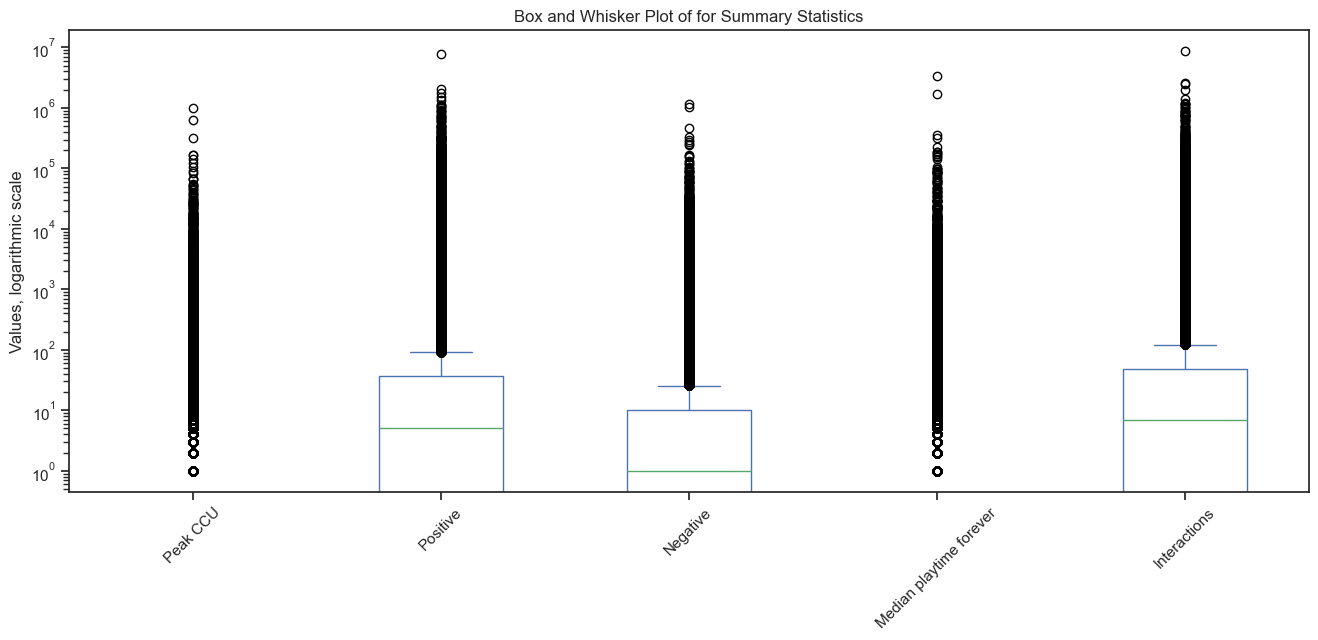

In [106]:
steam_games_df[[
    "Peak CCU",
    "Positive",
    "Negative",
    "Median playtime forever",
    "Interactions"
]].plot(
    kind="box",
    figsize=(16, 6),
    logy=True
    )

plt.title("Box and Whisker Plot of for Summary Statistics")

plt.ylabel("Values, logarithmic scale")
plt.xticks(rotation=45)
plt.show()

Like the summary statistics these box plots show that the magority of games have very low or 0 values and a few have extremly high values.  

In [103]:
genres_tags_df.describe(include="str")

,Genre / Tags
count,1299439
unique,453
top,Indie
freq,83058


### Genres Tags Investigation

In [104]:
genres_tags_df['Genre / Tags'].value_counts()

Genre / Tags
Indie            83058
Casual           54492
Singleplayer     50274
Adventure        49279
Action           49026
                 ...  
Masterpiece         12
VR Only             10
Lara Croft           1
Football             1
Tile-Matching        1
Name: count, Length: 453, dtype: int64

In [105]:
games_plus_tags_df = steam_games_df.merge(genres_tags_df, on="AppID", how="left")
games_plus_tags_df.head(8)

,AppID,Name,Release date,Peak CCU,Metacritic score,Positive,Negative,Median playtime forever,Estimated owners middle,Interactions,Genre / Tags
0,2539430,Black Dragon Mage Playtest,2023-08-01,0,<NA>,0,0,0,0,0,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,<NA>,252,3,8,10000,255,Adventure
2,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,<NA>,252,3,8,10000,255,Visual Novel
3,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,<NA>,252,3,8,10000,255,Anime
4,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,<NA>,252,3,8,10000,255,Cute
5,1034400,Mystery Solitaire The Black Raven,2019-05-06,0,<NA>,21,3,0,10000,24,Casual
6,1034400,Mystery Solitaire The Black Raven,2019-05-06,0,<NA>,21,3,0,10000,24,Card Game
7,1034400,Mystery Solitaire The Black Raven,2019-05-06,0,<NA>,21,3,0,10000,24,Solitaire


### Graphs

## Statistical analysis

## Graphical and numerical reporting

### Audience focussed charts

### Main Findings

### Recommendations